# Style transfer

В этом задании вы реализуете алгоритм переноса стиля. По сути, вам нужно просто объеденить тетрадки из прошлых двух уроков в одну.

In [2]:
import tensorflow as tf
import IPython.display as display
import time
from tqdm import tqdm_notebook as tqdm

#tf.enable_eager_execution()

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import  Path

In [4]:
#@title (вспомогательный код -- выполните клетку)

def clip_0_1(image):
    """
    Мы хотим уметь отображать нашу полученную картинку, а для этого ее значения должны
    находится в промежутке от 0 до 1. Наш алгоритм оптимизации этого нигде не учитывает
    поэтому к полученному изображению мы будем применять "обрезку" по значению

    """
    return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

def load_img(path_to_img, max_dim=512):
    """
    Данная функция считывает изображение с диска и приводит его к такому размеру,
    чтобы бОльшая сторона была равна max_dim пикселей.

    Для считывания изображения воспользуемся функциями tensorflow.
    """
    img = tf.io.read_file(path_to_img) # считываени файла
    img = tf.image.decode_image(img, channels=3)  # декодинг
    img = tf.image.convert_image_dtype(img, tf.float32) # uint8 -> float32, 255 -> 1

    shape = img.numpy().shape[:-1]
    long_dim = max(shape)
    scale = max_dim / long_dim
    new_shape = tuple((np.array(shape) * scale).astype(np.int32))

    img = tf.image.resize(img, new_shape) # изменение размера
    img = img[tf.newaxis, :] # добавляем batch dimension
    return img

def imshow(image, title=None):
    """
    Функция для отрисовки изображения
    """
    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)
    plt.axis('off')
    plt.imshow(image)
    if title:
        plt.title(title)

def show_pair(original, generated, title=None):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    imshow(original, 'Original Image')
    plt.subplot(1, 2, 2)
    imshow(generated, title)

In [5]:
def get_vgg_layers_model(layer_names):
    vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False

    outputs = [vgg.get_layer(name).output for name in layer_names]
    model = tf.keras.Model([vgg.input], outputs)
    return model

def gram_matrix(input_tensor):
    """
    В вычислении грам матрицы есть небольшие изменения по сравнению с прошлым уроком
    В этот раз мы делим не на W*H, а на W*H*C.
    Принципиально это ничего не меняет. Это один из способов по разному взвесить
    вклад разных слоев.
    Такое вычисление используется, например, здесь: https://arxiv.org/pdf/1603.08155.pdf
    """
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)

    num_locations = tf.cast(input_shape[1]*input_shape[2]*input_shape[3], tf.float32)
    return result/(num_locations)

## Задание 1. Определение экстрактора признаков.

Реализуйте класс `StyleAndContentExtractor`, который принимает на вход имена слоев, которые мы хотим извлекать из картинки для стилевого лосса (`style_layers`) и для контентного (`content_layers`).

Метод `__call__(self, inputs)` должен принимать на вход картинку, а возвращать словарь:
```
{
    "style" {"имя слоя": матрица грама выхода этого слоя для картинки inputs, ...},
    "content" {"имя слоя": активации этого слоя для картинки inputs}
 }

```

In [8]:
class StyleAndContentExtractor:
    def __init__(self, style_layers, content_layers):
        """
        style_layers -- список имен слоев для стиля
        content_layers -- список имен слоев для контента
        """
        self.style_layers = style_layers
        self.content_layers = content_layers

        # Собираем ВСЕ нужные слои
        all_layers = style_layers + content_layers

        self.vgg_outputs_model = get_vgg_layers_model(all_layers)
        # < YOUR CODE STARTS HERE >
        # self.vgg_outputs_model должна содержать модель, которая на выход
        # принимает картинку а выдает выходы style_layers и content_layers.
        # Вам пригодится функция get_vgg_layers_model
        # Обязательно 'заморозьте' модель!
        # КЛЮЧЕВОЕ: ЗАМОРАЖИВАЕМ ВЕСА!
        self.vgg_outputs_model.trainable = False

        # Также замораживаем все слои внутри модели
        for layer in self.vgg_outputs_model.layers:
            layer.trainable = False





        # < YOUR CODE ENDS HERE >

        assert self.vgg_outputs_model.trainable == False, "Модель должна быть 'заморожена'."
        assert len(self.vgg_outputs_model.outputs) == len(style_layers) + len(content_layers), \
        f"Количество выходов vgg_outputs_model должно быть равно сумме количества слоев стиля и контента."\
        f"{len(self.vgg_outputs_model.outputs)}!= {len(style_layers) + len(content_layers)}"

    def __call__(self, inputs):
        """
        На входе 4х мерный тензор (картинка). Значения пикселей ограничены 0..1!

        На выходе: {
            "style" : {
                        "имя слоя1": матрица грама выхода этого слоя для картинки inputs,
                        "имя слоя2": ...,
                        "имя слоя3": ...
                        },
            "content" {
                        "имя слоя1": активации этого слоя для картинки inputs
                        "имя слоя2": ...,
                        "имя слоя3": ...
                      }
                    }

        """
        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs*255.) # VGG препроцессинг
        outputs = self.vgg_outputs_model(preprocessed_input)
        # 3. Разделяем выходы на style и content
        #    Порядок: сначала все style слои, потом все content слои
        num_style_layers = len(self.style_layers)
        style_outputs_raw = outputs[:num_style_layers]  # первые N выходов для style
        content_outputs_raw = outputs[num_style_layers:]  # остальные для content

        # 4. Обрабатываем style выходы (преобразуем в Gram матрицы)
        style_outputs = []
        for style_tensor in style_outputs_raw:
            gram = gram_matrix(style_tensor)  # Применяем gram_matrix
            style_outputs.append(gram)

        # 5. Content выходы оставляем как есть (активации)
        content_outputs = content_outputs_raw  # Просто активации, без Gram

        # 6. Собираем словарь
        features_dict = {
            "style": {
                name: value for name, value in zip(self.style_layers, style_outputs)
            },
            "content": {
                name: value for name, value in zip(self.content_layers, content_outputs)
            }
        }
        # < YOUR CODE ENDS HERE >

        return features_dict

In [9]:
# выберем эти слои для сравнения матриц
style_layers = ['block1_conv1',
                'block2_conv1',
                'block3_conv1',
                'block4_conv1',
                'block5_conv1']
content_layers = ['block4_conv2']

extractor = StyleAndContentExtractor(style_layers=style_layers, content_layers=content_layers)
sample_image = np.ones((1, 512, 512, 3), dtype=np.float32)
style_and_content_targets = extractor(sample_image)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_22']
Received: inputs=Tensor(shape=(1, 512, 512, 3))
  warnings.warn(msg)


In [10]:
assert sorted(list(style_and_content_targets.keys())) == ["content", "style"], "StyleAndContentExtractor должен возвращать\
словарь с ключами 'style' и 'content'"

assert list(style_and_content_targets["style"]) == style_layers , \
f"Выбраны неправильные слои для стиля. {style_and_content_targets['style'].keys()}, а должны быть {style_layers}"
assert list(style_and_content_targets["content"]) == content_layers , \
f"Выбраны неправильные слои для контента. {style_and_content_targets['content'].keys()}, а должны быть {content_layers}"
print("Размеры выходов, отвечающих за стиль: ")
for k, v in style_and_content_targets['style'].items():
    shape = v.numpy().shape
    assert len(shape) == 3 and shape[1] == shape[2], f"Вероятно вы забыли посчитать матрицу Грама. \
    Размер выхода для стилевых слоев должен быть квадратным и с тремя размерностямя (1, W, W). Полученный {shape}"
    print(f"-- {k}:{v.numpy().shape}")
print("Размеры выходов, отвечающих за контент: ")
for k, v in style_and_content_targets['content'].items():
    print(f"-- {k}:{v.numpy().shape}")

print("-"*50, "\nSimple tests passed")

Размеры выходов, отвечающих за стиль: 
-- block1_conv1:(1, 64, 64)
-- block2_conv1:(1, 128, 128)
-- block3_conv1:(1, 256, 256)
-- block4_conv1:(1, 512, 512)
-- block5_conv1:(1, 512, 512)
Размеры выходов, отвечающих за контент: 
-- block4_conv2:(1, 64, 64, 512)
-------------------------------------------------- 
Simple tests passed


## Задание 2. Определение лосса.

Реализуйте функцию `style_content_loss(image, style_targets, content_targets)`.

Она принимает на вход текущую картинку, вычисляет для нее признаки с помощью `StyleAndContentExtractor`. Затем вычисляет MSE между его выходами (`features['style'], features['content']`) и `style_targets, content_targets` соответственно.

Таким образом получается два лосса -- `style_loss` и `content_loss`, которые нужно сложить предварительно взвесив с весами, которые определены ниже, для получения style transfer лосса.

Как и раньше к этому лоссу мы добавим total variation, чтобы на картинке было меньше шума. Его вес так же указан ниже.

In [36]:
# Вариант 1: Умеренное усиление стиля
#style_weight = 500.0    # Увеличили в 5 раз (было 100.0)
#content_weight = 2.0    # Уменьшили в 2.5 раза (было 5.0)
#tv_weight = 0.1

# Вариант 2: Сильное усиление стиля
#style_weight = 1000.0   # Увеличили в 10 раз
#content_weight = 1.0    # Уменьшили в 5 раз
#tv_weight = 0.05        # Можно немного уменьшить для более гладкого результата

# Вариант 3: Очень сильный стиль (буханка почти полностью в стиле печенья)
style_weight = 10000.0  # Увеличили в 100 раз
content_weight = 0.5    # Уменьшили в 10 раз
tv_weight = 0.01        # Минимальная регуляризация

# Вариант 4: Баланс для сохранения структуры
#style_weight = 200.0    # Увеличили в 2 раза
#content_weight = 10.0   # Увеличили в 2 раза (сохраняем структуру)
# Отношение style:content = 200:10 = 20:1 (было 100:5 = 20:1)
# Здесь соотношение то же, но абсолютные значения больше

In [37]:
def style_content_loss(image, style_targets, content_targets):
    """
    content_targets/style_targets -- {"имя_слоя": выход слоя/атрица грама, ...}

    1. Используйте extractor (глобальная переменная, не нужно определять в этой функции),
    чтобы получить текущие признаки из картинки image
    2. Посчитайте MSE между слоями в style_targets и  соответствующими текущими стилевыми признаками
    и затем сложите их. Запишите это в переменную style_loss
    3. Сделайте аналогичные операции для content_targets и поместите результат в content_loss

    Вам может пригодится tf.keras.losses.MeanSquaredError(), tf.add_n(),
    tf.image.total_variation(image)
    """


    # < YOUR CODE STARTS HERE >
    # 1. Получаем текущие признаки из изображения
    image_features = extractor(image)

    # 2. Вычисляем потери для стиля
    style_losses = []
    for layer_name in style_targets.keys():
        current_gram = image_features["style"][layer_name]
        target_gram = style_targets[layer_name]
        # Вычисляем MSE для матриц Грама
        mse = tf.reduce_mean(tf.square(current_gram - target_gram))
        style_losses.append(mse)

    # Суммируем все потери для стилевых слоев
    style_loss = tf.add_n(style_losses) / len(style_losses)  # усредняем

    # 3. Вычисляем потери для контента
    content_losses = []
    for layer_name in content_targets.keys():
        current_content = image_features["content"][layer_name]
        target_content = content_targets[layer_name]
        # Вычисляем MSE для активаций контента
        mse = tf.reduce_mean(tf.square(current_content - target_content))
        content_losses.append(mse)

    # Суммируем все потери для контентных слоев
    content_loss = tf.add_n(content_losses) / len(content_losses)  # усредняем






    # < YOUR CODE ENDS HERE >

    loss = style_weight * style_loss + content_weight * content_loss + tv_weight * tf.image.total_variation(image)
    return loss

## Задание 3. Запустите оптимизацию и получите перенесенный стиль.

Выберите картинки стиля и контента и получите перенос стиля. Вы можете использовать предложенные комбинации или выбрать свои (так даже интереснее!).

Предложенные параметры обучения и веса работают хорошо -- неплохой результат должен получиться без их изменения. Но эксперименты приветствуются. Размер картинки указан 1024. С таким размером оптимизация занимает около 15 минут.

Во вкладке Сolab -- Files (слева) вы увидите промежуточные результаты.

Для сдачи работы сохраните результаты выполнения в тетрадке (пример внизу).

In [38]:
def train_step(image, loss_func, optimizer):
    """
    Шаг оптимизации мы реализуем вручную (без .fit()). Такая реализация будет
    нам полезна в дальнейшем.

    """

    with tf.GradientTape() as tape: # "записываем" градиенты для дальнейшего использования
        loss = loss_func(image)
    grad = tape.gradient(loss, image) # dLoss/dImage
    optimizer.apply_gradients([(grad, image)]) # шаг градиентного спуск. в случае  GD: image = image - lambda*dLoss/dImage
                                         # картинка после этого шага изменилась!
    image.assign(clip_0_1(image)) # ~ image = clip_0_1(image), "обрезаем" неправильные значения
    return loss.numpy()

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Пытаемся загрузить: /content/drive/MyDrive/буханка.PNG
Пытаемся загрузить: /content/drive/MyDrive/детские рисунки.PNG

Проверка: Content Image
Путь: /content/drive/MyDrive/буханка.PNG
✓ Файл существует!


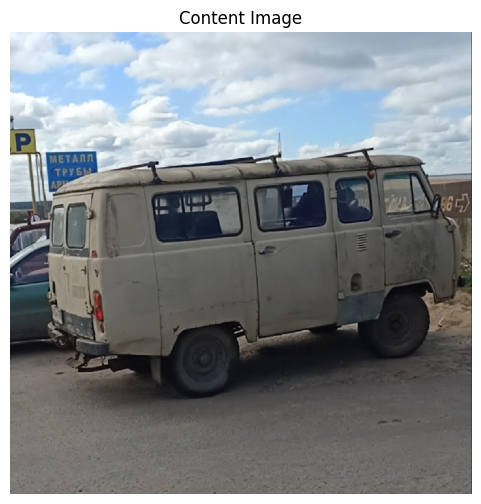


Свойства Content Image:
  Размер PIL изображения: (1024, 1024)
  Размер массива: (1024, 1024, 3)
  Максимальное значение: 255
  Минимальное значение: 0
  Тип данных: uint8
  Размер тензора для модели: (1, 1024, 1024, 3)

Проверка: Style Image
Путь: /content/drive/MyDrive/детские рисунки.PNG
✓ Файл существует!


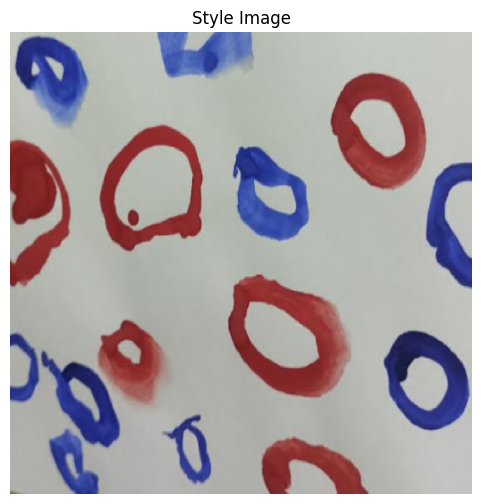


Свойства Style Image:
  Размер PIL изображения: (1024, 1024)
  Размер массива: (1024, 1024, 3)
  Максимальное значение: 223
  Минимальное значение: 9
  Тип данных: uint8
  Размер тензора для модели: (1, 1024, 1024, 3)

✓ Оба изображения успешно загружены!


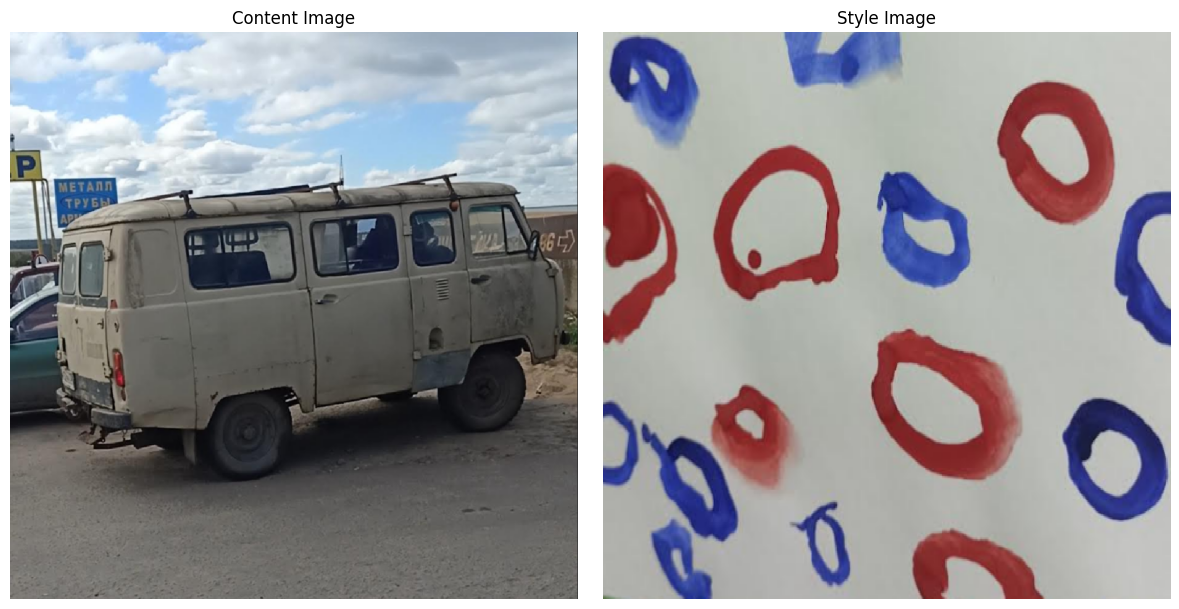

In [39]:
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt
import numpy as np
import os


content_file = 'буханка'
style_file = 'детские рисунки'
# 1. ПРАВИЛЬНЫЙ путь с заглавными .PNG
content_path = f'/content/drive/MyDrive/{content_file}.PNG'  # ← .PNG с заглавными!
style_path = f'/content/drive/MyDrive/{style_file}.PNG'  # ← .PNG с заглавными!
print(f"Пытаемся загрузить: {content_path}")
print(f"Пытаемся загрузить: {style_path}")


# Функция для загрузки и проверки изображений
def load_and_check_image(image_path, name, display=True):
    print(f"\n{'='*30}")
    print(f"Проверка: {name}")
    print(f"Путь: {image_path}")

    if os.path.exists(image_path):
        print("✓ Файл существует!")

        # Загружаем изображение (для проверки используем PIL)
        pil_image = load_img(image_path, target_size=(1024, 1024))

        # Преобразуем для TensorFlow модели
        img_array = np.array(pil_image)

        if img_array.ndim == 2:  # Если черно-белое
            img_array = np.stack([img_array]*3, axis=-1)

        # Нормализуем к 0-1 для модели
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32) / 255.0
        img_tensor = tf.expand_dims(img_tensor, axis=0)

        # Отображаем
        if display:
            plt.figure(figsize=(6, 6))
            imshow(img_tensor, name)
            plt.show()

        print(f"\nСвойства {name}:")
        print(f"  Размер PIL изображения: {pil_image.size}")
        print(f"  Размер массива: {img_array.shape}")
        print(f"  Максимальное значение: {img_array.max()}")
        print(f"  Минимальное значение: {img_array.min()}")
        print(f"  Тип данных: {img_array.dtype}")
        print(f"  Размер тензора для модели: {img_tensor.shape}")

        return img_tensor

    else:
        print("✗ Файл не найден!")

        # Покажем, что реально есть в папке
        folder = '/content/drive/MyDrive'
        print(f"\nРеальные файлы в папке {folder}:")
        files = os.listdir(folder)
        if files:
            print("  Доступные файлы:")
            for f in sorted(files)[:20]:  # Покажем первые 20
                print(f"  - {f}")
            if len(files) > 20:
                print(f"  ... и еще {len(files)-20} файлов")
        else:
            print("  Папка пуста!")

        return None

# Загружаем и проверяем оба изображения
content_image = load_and_check_image(content_path, "Content Image")
style_image = load_and_check_image(style_path, "Style Image")

# Проверяем, что оба изображения загрузились
if content_image is not None and style_image is not None:
    print("\n" + "="*50)
    print("✓ Оба изображения успешно загружены!")
    print("="*50)

    # Отображаем оба изображения рядом для сравнения
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    imshow(content_image, "Content Image")

    plt.subplot(1, 2, 2)
    imshow(style_image, "Style Image")

    plt.tight_layout()
    plt.show()

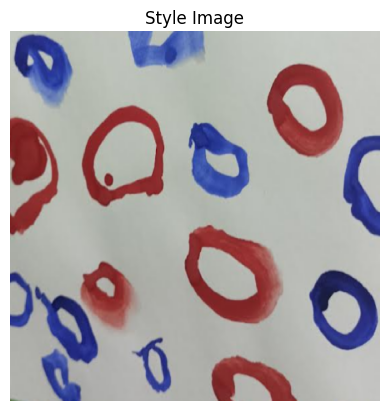

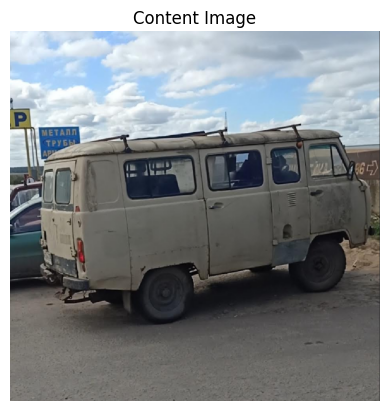

In [40]:
#content_path = tf.keras.utils.get_file('krem.jpg','https://media-cdn.tripadvisor.com/media/photo-s/16/44/b4/17/red-square-and-kremlin.jpg')
#style_path = tf.keras.utils.get_file('klimt.jpg','https://images.huffingtonpost.com/2012-11-28-2klimtderkuss1908.jpeg')
#content_path = tf.keras.utils.get_file('lala2.jpg','https://thoughtcatalog.files.wordpress.com/2017/02/screen-shot-2017-02-06-at-12-40-06-pm.png')
#style_path = tf.keras.utils.get_file('starry.jpg','https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/1280px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg')

#content_image = load_img(content_path, 1024)
#style_image = load_img(style_path, 1024)

style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']
plt.figure()
imshow(style_image, "Style Image")
plt.figure()
imshow(content_image, "Content Image")

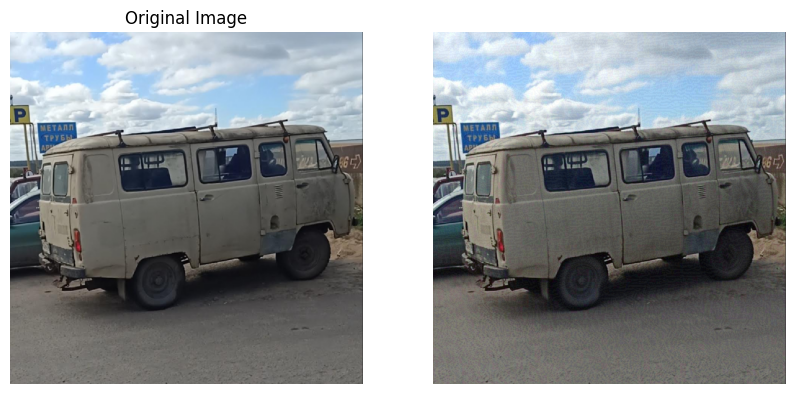

In [41]:
def loss(image):
    return style_content_loss(image, style_targets, content_targets)

image = tf.Variable(content_image) # начинаем не с шума а с content_image!. Так оптимизация сходится быстрее.
# вы можете попробовать самостоятельно начинать оптимизацию со случайного прибижения. оптимизировать будет сложнее
# но результаты могут получиться интереснее. в таком случая рекомендуется начать с размера картики 512 а не 1024 как по
# умолчанию. изменить это можно в клетке выше.

opt = tf.keras.optimizers.Adam(learning_rate=0.02, beta_1=0.99, epsilon=1e-1)
# сделаем шаг оптимизации -- убедимся что все работает без ошибок.
train_step(image, loss_func=loss, optimizer=opt)
show_pair(content_image, image)

Total time: 636.6


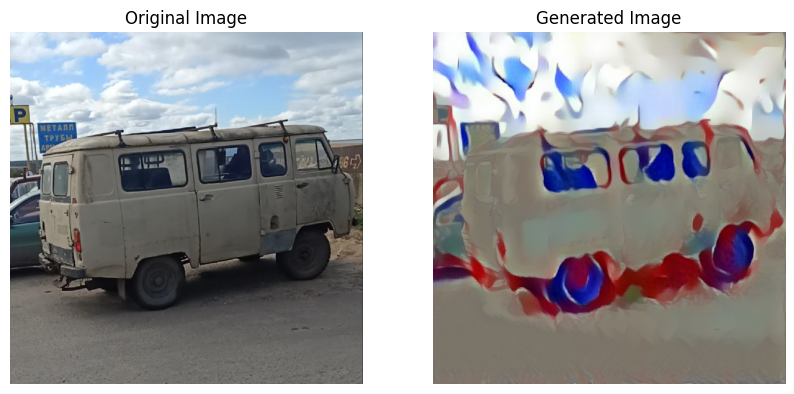

In [42]:
start = time.time()

content_name = Path(content_path).stem
style_name = Path(style_path).stem

epochs = 20
steps_per_epoch = 50

step = 0
for n in range(epochs):
  for m in tqdm(range(steps_per_epoch)):
    step += 1
    train_step(image, loss_func=loss, optimizer=opt)

  display.clear_output(wait=True)
  show_pair(content_image, image, f"Generated Image.Train step: {step}")
  plt.imsave(f"{content_name}@{style_name}_{step}.png", image.numpy()[0])
  plt.show()

end = time.time()
display.clear_output(wait=True)
show_pair(content_image, image, f"Generated Image")
print("Total time: {:.1f}".format(end-start))

✓ Результат сохранен: /content/drive/MyDrive/result-детские рисунки.png


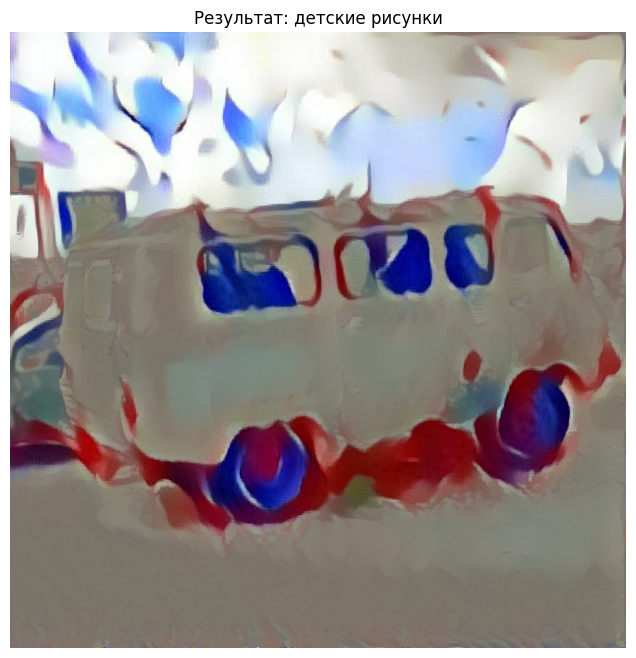

In [43]:
# 1. Извлекаем изображение из тензора
image_np = image.numpy()[0]  # [1, H, W, 3] -> [H, W, 3]

# 2. Убедимся, что значения в диапазоне 0-1
if image_np.max() > 1.0:
    image_np = image_np / 255.0

# 3. Обрезаем значения до 0-1
image_np = np.clip(image_np, 0, 1)

# 4. Сохраняем по указанному пути
save_path = f'/content/drive/MyDrive/result-{style_file}.png'
plt.imsave(save_path, image_np)

print(f"✓ Результат сохранен: {save_path}")

# 5. Показываем сохраненное изображение
plt.figure(figsize=(8, 8))
plt.imshow(image_np)
plt.axis('off')
plt.title(f"Результат: {style_file}")
plt.show()